# Exogenous Virtual Sensor and Monthly Generalization

This notebook develops **Option C**: estimate `SLURRY_FREE_ACID` when a new CSV contains process measurements but no free-acid value at any timestamp.

\[
\hat y_t=f(X_t,X_{t-1},\ldots),
\qquad y_t=\text{SLURRY\_FREE\_ACID}_t.
\]

The model never receives the current target, target lags, future targets, or target-derived statistics at inference. The goal is a target-free soft sensor, not the early-warning model from Notebook 04.

## 1. Research basis, configuration, and reproducibility


### 1.1 Recent research translated into testable choices


Recent industrial soft-sensor work emphasizes dynamic latent-variable models, just-in-time local learning, adaptation to concept drift, semi-supervised representation learning, and uncertainty quantification. For this dataset, the defensible tests are:

1. **Dynamic PLS** as a compact, interpretable industrial baseline.
2. **Local neighbor regression** as a practical just-in-time approximation for multimodal operation.
3. **Modern gradient boosting** for nonlinear tabular relationships.
4. **Chronological blending** to combine complementary validation-selected models.
5. **Conformal-style empirical intervals and input drift scores** so unsupported predictions can be flagged.

Deep semi-supervised and foundation models are not treated as automatic breakthroughs: the available labeled dataset covers only one month, and TabPFN's published main regime is small-to-medium tables, while our prepared training set exceeds 30,000 rows. Sources consulted include:

- Zhang et al. (2023), *Dynamic transfer soft sensor for concept drift adaptation*, Journal of Process Control, DOI `10.1016/j.jprocont.2023.01.012`.
- Zhang et al. (2024), *Adaptive soft sensor modeling ... improved just-in-time learning and random mapping PLS*, Journal of Chemometrics, DOI `10.1002/cem.3554`.
- Hollmann et al. (2025), *Accurate predictions on small data with a tabular foundation model*, Nature, DOI `10.1038/s41586-024-08328-6`.
- Zhang and Zhou (2025), *Uncertainty Quantification Based on Conformal Prediction for Industrial Time Series With Distribution Shift*, IEEE TII, DOI `10.1109/TII.2025.3529920`.
- Prokhorenkova et al. (2018), *CatBoost: unbiased boosting with categorical features*, NeurIPS. CatBoost is not installed here; installed XGBoost and LightGBM are evaluated instead.


### 1.2 Imports


In [1]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import json, time, warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")


### 1.3 Central configuration


In [2]:
RANDOM_STATE = 42
FEATURE_SETS = ["A_raw", "D_full"]
TARGET = "SLURRY_FREE_ACID"
TIME_COL = "Date"
CONFORMAL_ALPHA = 0.10
BLEND_GRID = np.linspace(0, 1, 11)
PERMUTATION_ROWS = 2000

PREPARATION_NOTEBOOK = Path("02_feature_engineering_data_preparation.ipynb")
OUTPUT_DIR = Path("../reports/exogenous_virtual_sensor_artifacts")
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
for p in [OUTPUT_DIR, FIGURE_DIR, MODEL_DIR]: p.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)


## 2. Recover and validate the prepared process inputs


### 2.1 Replay Notebook 02 exactly


In [3]:
def recover_prepared_namespace(path):
    nb = json.loads(path.read_text(encoding="utf-8"))
    ns, executed = {"display": lambda x: None}, 0
    with redirect_stdout(StringIO()):
        for cell in nb["cells"]:
            if cell.get("cell_type") != "code": continue
            src = cell.get("source", "")
            src = "".join(src) if isinstance(src, list) else src
            if src.strip().startswith("import matplotlib.pyplot as plt"): break
            exec(compile(src, f"prep_cell_{executed}", "exec"), ns)
            executed += 1
    return ns, executed

prep, replayed = recover_prepared_namespace(PREPARATION_NOTEBOOK)
modeling_datasets, prepared = prep["modeling_datasets"], prep["prepared"]
raw_df = prep["df"].sort_values(prep["TIME_COL"]).reset_index(drop=True)
TARGET, TIME_COL = prep["TARGET"], prep["TIME_COL"]
print(f"Recovered {len(modeling_datasets)} configurations from {replayed} preparation cells.")


Recovered 16 configurations from 37 preparation cells.


### 2.2 Reframe the inherited rows for current-time soft sensing


In [4]:
current_target = raw_df.set_index(TIME_COL)[TARGET]
virtual_sensor_data = {}
dimension_rows = []

for fs in FEATURE_SETS:
    inherited = modeling_datasets[(1, fs)]
    parts = prepared[(1, fs)]
    splits = {}
    for i, split in enumerate(["train", "valid", "test"]):
        timestamps = parts[f"{split}_df"][TIME_COL].reset_index(drop=True)
        y = timestamps.map(current_target)
        usable = y.notna()
        splits[split] = {
            "timestamp": timestamps.loc[usable].reset_index(drop=True),
            "y": y.loc[usable].reset_index(drop=True),
            "X_tree": inherited["X"]["tree"][i].reset_index(drop=True).loc[usable].reset_index(drop=True),
            "X_standard": inherited["X"]["standard"][i].reset_index(drop=True).loc[usable].reset_index(drop=True),
        }
    virtual_sensor_data[fs] = {"splits": splits, "features": inherited["features"],
                               "pipelines": inherited["pipelines"]}
    dimension_rows.append({"feature_set": fs, "feature_count": len(inherited["features"]),
                           **{f"{s}_rows": len(splits[s]["y"]) for s in splits}})

virtual_sensor_dimensions = pd.DataFrame(dimension_rows)
display(virtual_sensor_dimensions)


,feature_set,feature_count,train_rows,valid_rows,test_rows
0,A_raw,21,30940,6628,6632
1,D_full,178,30940,6628,6632


### 2.3 Leakage and alignment gate


In [5]:
integrity_rows = []
for fs, payload in virtual_sensor_data.items():
    s = payload["splits"]
    integrity_rows.append({"feature_set": fs,
        "target_absent": TARGET not in payload["features"],
        "target_derived_absent": not any(c.startswith(TARGET) for c in payload["features"]),
        "future_target_absent": not any("t_plus" in c for c in payload["features"]),
        "chronological": s["train"]["timestamp"].max() < s["valid"]["timestamp"].min() < s["test"]["timestamp"].min(),
        "aligned_columns": list(s["train"]["X_tree"].columns) == list(s["valid"]["X_tree"].columns) == list(s["test"]["X_tree"].columns),
        "no_missing_after_preprocessing": all(not s[x][v].isna().any().any() for x in s for v in ["X_tree", "X_standard"])})
input_integrity = pd.DataFrame(integrity_rows)
assert input_integrity.drop(columns="feature_set").all().all()
display(input_integrity)


,feature_set,target_absent,target_derived_absent,future_target_absent,chronological,aligned_columns,no_missing_after_preprocessing
0,A_raw,True,True,True,True,True,True
1,D_full,True,True,True,True,True,True


### 2.4 Observations


- The model inputs contain process measurements and their accepted temporal/process-aware derivatives only.
- Current target labels are used during training and evaluation, but never appear in `X`.
- A future target-free CSV can be processed using the saved Notebook 02 feature/preprocessing objects, then passed to the final model.


## 3. Honest target-free baselines and metrics


### 3.1 Regression metrics


In [6]:
def metrics(y, p):
    y, p = np.asarray(y), np.asarray(p)
    e, ae = p-y, np.abs(p-y)
    return {"mae": mean_absolute_error(y,p), "rmse": mean_squared_error(y,p)**.5,
            "median_ae": median_absolute_error(y,p), "r2": r2_score(y,p), "bias": e.mean(),
            "p90_ae": np.quantile(ae,.9), "p95_ae": np.quantile(ae,.95)}
def pref(d, x): return {f"{x}_{k}":v for k,v in d.items()}


### 3.2 Training-mean and time-of-day baselines


In [7]:
baseline_rows, baseline_predictions = [], []
base = virtual_sensor_data["A_raw"]["splits"]
train_mean = float(base["train"]["y"].mean())
minute_of_day_train = base["train"]["timestamp"].dt.hour*60 + base["train"]["timestamp"].dt.minute
tod_lookup = pd.DataFrame({"minute": minute_of_day_train, "y": base["train"]["y"]}).groupby("minute").y.mean()

for name in ["training_mean", "time_of_day_mean"]:
    row = {"model": name, "feature_set": "baseline"}
    for split in ["valid", "test"]:
        ts, y = base[split]["timestamp"], base[split]["y"]
        if name == "training_mean": pred = np.full(len(y), train_mean)
        else:
            minute = ts.dt.hour*60 + ts.dt.minute
            pred = minute.map(tod_lookup).fillna(train_mean).to_numpy()
        row.update(pref(metrics(y,pred), split))
        baseline_predictions.append(pd.DataFrame({"timestamp":ts,"split":split,"model":name,"actual":y,"prediction":pred}))
    baseline_rows.append(row)
baseline_results = pd.DataFrame(baseline_rows)
baseline_predictions = pd.concat(baseline_predictions, ignore_index=True)
display(baseline_results)


,model,feature_set,valid_mae,valid_rmse,valid_median_ae,valid_r2,valid_bias,valid_p90_ae,valid_p95_ae,test_mae,test_rmse,test_median_ae,test_r2,test_bias,test_p90_ae,test_p95_ae
0,training_mean,baseline,0.385040,0.46873,0.351500,-0.145245,0.166926,0.74352,0.850870,0.354763,0.453571,0.310780,-0.000399,-0.009063,0.676780,0.79378
1,time_of_day_mean,baseline,0.360171,0.45052,0.310886,-0.057990,0.172753,0.72849,0.845748,0.350905,0.454556,0.310813,-0.004748,-0.009508,0.646616,0.77551


## 4. Controlled global and local soft-sensor benchmark


### 4.1 Small, interpretable search spaces


In [8]:
MODEL_SPECS = {
 "ridge": {"variant":"X_standard", "candidates":[{"alpha":1.0},{"alpha":10.0}]},
 "pls": {"variant":"X_standard", "candidates":[{"n_components":5},{"n_components":10}]},
 "knn_local": {"variant":"X_standard", "candidates":[{"n_neighbors":25,"weights":"distance"},{"n_neighbors":75,"weights":"distance"}]},
 "extra_trees": {"variant":"X_tree", "candidates":[{"n_estimators":60,"min_samples_leaf":2,"max_features":.8},{"n_estimators":60,"min_samples_leaf":5,"max_features":.7}]},
 "hist_gradient": {"variant":"X_tree", "candidates":[{"max_iter":80,"learning_rate":.05,"max_leaf_nodes":15},{"max_iter":80,"learning_rate":.08,"max_leaf_nodes":31}]},
 "xgboost": {"variant":"X_tree", "candidates":[{"n_estimators":150,"max_depth":4,"learning_rate":.05,"subsample":.8,"colsample_bytree":.8},{"n_estimators":150,"max_depth":6,"learning_rate":.05,"subsample":.8,"colsample_bytree":.8}]},
 "lightgbm": {"variant":"X_tree", "candidates":[{"n_estimators":150,"num_leaves":15,"learning_rate":.05,"min_child_samples":40},{"n_estimators":150,"num_leaves":31,"learning_rate":.05,"min_child_samples":40}]},
}

def build_model(name, p):
    if name=="ridge": return Ridge(**p)
    if name=="pls": return PLSRegression(**p, scale=False, max_iter=500)
    if name=="knn_local": return KNeighborsRegressor(**p, n_jobs=-1)
    if name=="extra_trees": return ExtraTreesRegressor(**p, random_state=RANDOM_STATE, n_jobs=-1)
    if name=="hist_gradient": return HistGradientBoostingRegressor(**p, random_state=RANDOM_STATE, early_stopping=False)
    if name=="xgboost": return XGBRegressor(**p, objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1)
    return LGBMRegressor(**p, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)

search_space = pd.DataFrame([{"model":m,"candidate":i,"parameters":json.dumps(p)}
                             for m,s in MODEL_SPECS.items() for i,p in enumerate(s["candidates"],1)])
display(search_space)


,model,candidate,parameters
0,ridge,1,"{""alpha"": 1.0}"
1,ridge,2,"{""alpha"": 10.0}"
2,pls,1,"{""n_components"": 5}"
3,pls,2,"{""n_components"": 10}"
4,knn_local,1,"{""n_neighbors"": 25, ""weights"": ""distance""}"
5,knn_local,2,"{""n_neighbors"": 75, ""weights"": ""distance""}"
6,extra_trees,1,"{""n_estimators"": 60, ""min_samples_leaf"": 2, ""m..."
7,extra_trees,2,"{""n_estimators"": 60, ""min_samples_leaf"": 5, ""m..."
8,hist_gradient,1,"{""max_iter"": 80, ""learning_rate"": 0.05, ""max_l..."
9,hist_gradient,2,"{""max_iter"": 80, ""learning_rate"": 0.08, ""max_l..."


### 4.2 Tune on chronological validation and evaluate test once


In [9]:
search_rows, result_rows, prediction_frames, selected_models = [], [], [], {}
for fs, payload in virtual_sensor_data.items():
    s = payload["splits"]
    for name, spec in MODEL_SPECS.items():
        candidates=[]
        for cid, params in enumerate(spec["candidates"],1):
            model=build_model(name,params); start=time.perf_counter()
            model.fit(s["train"][spec["variant"]],s["train"]["y"])
            fit=time.perf_counter()-start
            vp=np.asarray(model.predict(s["valid"][spec["variant"]])).ravel(); vm=metrics(s["valid"]["y"],vp)
            search_rows.append({"feature_set":fs,"model":name,"candidate":cid,"parameters":json.dumps(params,sort_keys=True),"fit_seconds":fit,**pref(vm,"valid")})
            candidates.append((vm["rmse"],cid,params,model,fit,vp))
        _,cid,params,model,fit,vp=min(candidates,key=lambda z:z[0])
        start=time.perf_counter(); tp=np.asarray(model.predict(s["test"][spec["variant"]])).ravel(); infer=time.perf_counter()-start
        vm,tm=metrics(s["valid"]["y"],vp),metrics(s["test"]["y"],tp)
        result_rows.append({"feature_set":fs,"model":name,"feature_count":len(payload["features"]),
                            "selected_candidate":cid,"selected_parameters":json.dumps(params,sort_keys=True),
                            "training_seconds":fit,"test_inference_seconds":infer,**pref(vm,"valid"),**pref(tm,"test")})
        selected_models[(fs,name)]=model
        for split,pred in [("valid",vp),("test",tp)]:
            prediction_frames.append(pd.DataFrame({"timestamp":s[split]["timestamp"],"split":split,"feature_set":fs,
                "model":name,"actual":s[split]["y"],"prediction":pred}))

hyperparameter_search=pd.DataFrame(search_rows)
benchmark_results=pd.DataFrame(result_rows)
model_predictions=pd.concat(prediction_frames,ignore_index=True)
display(benchmark_results.sort_values("valid_rmse"))


,feature_set,model,feature_count,selected_candidate,selected_parameters,training_seconds,test_inference_seconds,valid_mae,valid_rmse,valid_median_ae,valid_r2,valid_bias,valid_p90_ae,valid_p95_ae,test_mae,test_rmse,test_median_ae,test_r2,test_bias,test_p90_ae,test_p95_ae
7,D_full,ridge,178,2,"{""alpha"": 10.0}",0.109834,0.004483,0.260730,0.338090,0.221433,0.404176,0.075511,0.507442,0.600645,0.272790,0.334667,0.247860,0.455362,0.012653,0.510847,0.600581
13,D_full,lightgbm,178,2,"{""learning_rate"": 0.05, ""min_child_samples"": 4...",5.450858,0.053322,0.269326,0.339323,0.234525,0.399821,0.105458,0.537378,0.636839,0.253865,0.309656,0.230285,0.533725,0.022870,0.484094,0.558874
10,D_full,extra_trees,178,1,"{""max_features"": 0.8, ""min_samples_leaf"": 2, ""...",26.046660,0.083141,0.272373,0.341487,0.240588,0.392144,0.096829,0.538019,0.634749,0.246169,0.306216,0.217721,0.544027,0.034211,0.482205,0.563128
11,D_full,hist_gradient,178,2,"{""learning_rate"": 0.08, ""max_iter"": 80, ""max_l...",5.521130,0.090813,0.276328,0.345915,0.243655,0.376275,0.117817,0.544121,0.643018,0.255762,0.314233,0.232741,0.519840,0.019644,0.486237,0.559638
12,D_full,xgboost,178,2,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",9.527136,0.058809,0.279990,0.355940,0.246103,0.339601,0.106554,0.553707,0.657109,0.250007,0.306678,0.227728,0.542651,0.033679,0.477250,0.556450
8,D_full,pls,178,2,"{""n_components"": 10}",0.918642,0.016055,0.282017,0.356475,0.244789,0.337614,0.083672,0.565919,0.663983,0.294264,0.356491,0.269488,0.382012,-0.026985,0.544824,0.628605
0,A_raw,ridge,21,1,"{""alpha"": 1.0}",0.017025,0.001563,0.296476,0.374711,0.254156,0.268111,0.073284,0.591750,0.696382,0.306329,0.378864,0.273564,0.302007,0.026038,0.596433,0.697327
1,A_raw,pls,21,2,"{""n_components"": 10}",0.119716,0.002209,0.297704,0.376263,0.255004,0.262033,0.073130,0.596211,0.700318,0.305631,0.377834,0.273342,0.305801,0.022075,0.592729,0.695304
3,A_raw,extra_trees,21,2,"{""max_features"": 0.7, ""min_samples_leaf"": 5, ""...",1.838521,0.069203,0.309957,0.387567,0.273027,0.217027,0.116941,0.623237,0.730900,0.273448,0.339135,0.241541,0.440721,0.070883,0.540554,0.621735
5,A_raw,xgboost,21,1,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.957970,0.012863,0.331604,0.414751,0.289828,0.103341,0.131496,0.670162,0.786931,0.347234,0.419842,0.319757,0.142855,0.161056,0.666982,0.756287


### 4.3 Observations: strongest individual virtual sensor


In [10]:
best_individual=benchmark_results.sort_values("valid_rmse").iloc[0]
display(best_individual.to_frame("value"))
print("Selection uses validation RMSE; test metrics are reported once after selection.")


,value
feature_set,D_full
model,ridge
feature_count,178
selected_candidate,2
selected_parameters,"{""alpha"": 10.0}"
training_seconds,0.109834
test_inference_seconds,0.004483
valid_mae,0.26073
valid_rmse,0.33809
valid_median_ae,0.221433


Selection uses validation RMSE; test metrics are reported once after selection.


## 5. Chronological ensemble without target input


### 5.1 Select complementary models and tune blend weights on validation


In [11]:
ranked=benchmark_results.sort_values("valid_rmse")
blend_members=[]
for _,row in ranked.iterrows():
    key=(row.feature_set,row.model)
    if not blend_members or row.model != blend_members[0][1]:
        blend_members.append(key)
    if len(blend_members)==2: break

valid_wide=(model_predictions.query("split=='valid'")
            .pivot(index="timestamp",columns=["feature_set","model"],values="prediction"))
test_wide=(model_predictions.query("split=='test'")
           .pivot(index="timestamp",columns=["feature_set","model"],values="prediction"))
valid_actual=model_predictions.query("split=='valid'").drop_duplicates("timestamp").set_index("timestamp").actual.reindex(valid_wide.index)
test_actual=model_predictions.query("split=='test'").drop_duplicates("timestamp").set_index("timestamp").actual.reindex(test_wide.index)

blend_trials=[]
for w in BLEND_GRID:
    pred=w*valid_wide[blend_members[0]]+(1-w)*valid_wide[blend_members[1]]
    blend_trials.append({"weight_first":w,"weight_second":1-w,"valid_rmse":metrics(valid_actual,pred)["rmse"]})
blend_search=pd.DataFrame(blend_trials)
best_weight=float(blend_search.sort_values("valid_rmse").iloc[0].weight_first)
blend_valid=best_weight*valid_wide[blend_members[0]]+(1-best_weight)*valid_wide[blend_members[1]]
blend_test=best_weight*test_wide[blend_members[0]]+(1-best_weight)*test_wide[blend_members[1]]
blend_result=pd.DataFrame([{ "model":"validation_weighted_blend","feature_set":"mixed",
    "members":json.dumps(blend_members),"weight_first":best_weight,"weight_second":1-best_weight,
    **pref(metrics(valid_actual,blend_valid),"valid"),**pref(metrics(test_actual,blend_test),"test")}])
display(blend_result)


,model,feature_set,members,weight_first,weight_second,valid_mae,valid_rmse,valid_median_ae,valid_r2,valid_bias,valid_p90_ae,valid_p95_ae,test_mae,test_rmse,test_median_ae,test_r2,test_bias,test_p90_ae,test_p95_ae
0,validation_weighted_blend,mixed,"[[""D_full"", ""ridge""], [""D_full"", ""lightgbm""]]",0.5,0.5,0.25097,0.320666,0.214443,0.464007,0.090485,0.502892,0.596258,0.249015,0.301377,0.229341,0.558323,0.017762,0.458777,0.536273


### 5.2 Compare all candidates against target-free baselines


In [12]:
comparison=pd.concat([baseline_results,benchmark_results,blend_result],ignore_index=True,sort=False)
comparison["test_rmse_improvement_over_train_mean_pct"]=100*(baseline_results.iloc[0].test_rmse-comparison.test_rmse)/baseline_results.iloc[0].test_rmse
display(comparison.sort_values("valid_rmse")[["feature_set","model","valid_rmse","test_rmse","test_mae","test_r2","test_rmse_improvement_over_train_mean_pct"]])


,feature_set,model,valid_rmse,test_rmse,test_mae,test_r2,test_rmse_improvement_over_train_mean_pct
16,mixed,validation_weighted_blend,0.320666,0.301377,0.249015,0.558323,33.554489
9,D_full,ridge,0.338090,0.334667,0.272790,0.455362,26.215124
15,D_full,lightgbm,0.339323,0.309656,0.253865,0.533725,31.729329
12,D_full,extra_trees,0.341487,0.306216,0.246169,0.544027,32.487699
13,D_full,hist_gradient,0.345915,0.314233,0.255762,0.519840,30.720259
14,D_full,xgboost,0.355940,0.306678,0.250007,0.542651,32.385931
10,D_full,pls,0.356475,0.356491,0.294264,0.382012,21.403500
2,A_raw,ridge,0.374711,0.378864,0.306329,0.302007,16.470731
3,A_raw,pls,0.376263,0.377834,0.305631,0.305801,16.698003
5,A_raw,extra_trees,0.387567,0.339135,0.273448,0.440721,25.230002


## 6. Stability, drift, and unsupported-operation diagnostics


### 6.1 Rolling validation blocks


In [13]:
best_key=(best_individual.feature_set,best_individual.model)
best_pred=model_predictions.query("feature_set==@best_key[0] and model==@best_key[1] and split=='valid'").copy()
best_pred["validation_block"]=pd.qcut(np.arange(len(best_pred)),4,labels=["V1","V2","V3","V4"])
rolling_validation=(best_pred.groupby("validation_block",observed=True)
                    .apply(lambda g:pd.Series(metrics(g.actual,g.prediction)),include_groups=False).reset_index())
display(rolling_validation)


,validation_block,mae,rmse,median_ae,r2,bias,p90_ae,p95_ae
0,V1,0.340833,0.449315,0.278740,0.124202,0.194258,0.658290,0.878293
1,V2,0.209739,0.275307,0.179901,0.399880,0.005128,0.422398,0.488794
2,V3,0.199651,0.253180,0.178074,0.535351,0.058138,0.404875,0.460336
3,V4,0.292698,0.339766,0.283921,0.307596,0.044520,0.522839,0.585591


### 6.2 Input-space drift score available without target labels


In [14]:
best_fs=best_individual.feature_set; s=virtual_sensor_data[best_fs]["splits"]
def drift_score(X): return np.sqrt(np.mean(np.square(np.asarray(X)),axis=1))
train_drift=drift_score(s["train"]["X_standard"])
drift_threshold=float(np.quantile(train_drift,.99))
drift_frames=[]
for split in ["valid","test"]:
    scores=drift_score(s[split]["X_standard"])
    drift_frames.append(pd.DataFrame({"timestamp":s[split]["timestamp"],"split":split,"drift_score":scores,
                                      "outside_training_envelope":scores>drift_threshold}))
drift_diagnostics=pd.concat(drift_frames,ignore_index=True)
drift_summary=drift_diagnostics.groupby("split").outside_training_envelope.agg(["count","sum","mean"]).reset_index()
display(drift_summary)


,split,count,sum,mean
0,test,6632,91,0.013721
1,valid,6628,0,0.000000


### 6.3 Error inside and outside the training envelope


In [15]:
best_all=model_predictions.query("feature_set==@best_key[0] and model==@best_key[1]").merge(drift_diagnostics,on=["timestamp","split"])
drift_error_metrics=(best_all.groupby(["split","outside_training_envelope"])
                     .apply(lambda g:pd.Series(metrics(g.actual,g.prediction)),include_groups=False).reset_index())
display(drift_error_metrics)


,split,outside_training_envelope,mae,rmse,median_ae,r2,bias,p90_ae,p95_ae
0,test,False,0.269700,0.327974,0.247444,0.367824,0.013204,0.505160,0.588713
1,test,True,0.494946,0.656328,0.385559,0.258246,-0.026966,0.914502,0.992570
2,valid,False,0.260730,0.338090,0.221433,0.404176,0.075511,0.507442,0.600645


## 7. Empirical prediction intervals


### 7.1 Calibrate on validation residuals only


In [16]:
best_valid=best_all.query("split=='valid'")
q=float(np.quantile(np.abs(best_valid.actual-best_valid.prediction),1-CONFORMAL_ALPHA,method="higher"))
best_test=best_all.query("split=='test'").copy()
best_test["lower_90"]=best_test.prediction-q
best_test["upper_90"]=best_test.prediction+q
best_test["covered_90"]=(best_test.actual>=best_test.lower_90)&(best_test.actual<=best_test.upper_90)
interval_summary=pd.DataFrame([{"nominal_coverage":1-CONFORMAL_ALPHA,"validation_quantile":q,
    "test_empirical_coverage":best_test.covered_90.mean(),"mean_interval_width":2*q,
    "coverage_in_envelope":best_test.loc[~best_test.outside_training_envelope,"covered_90"].mean(),
    "coverage_outside_envelope":best_test.loc[best_test.outside_training_envelope,"covered_90"].mean()}])
display(interval_summary)


,nominal_coverage,validation_quantile,test_empirical_coverage,mean_interval_width,coverage_in_envelope,coverage_outside_envelope
0,0.9,0.507493,0.896562,1.014986,0.901544,0.538462


### 7.2 Interpretation limitation


This is a chronological split-conformal-style diagnostic. Because adjacent industrial observations are dependent and the process distribution shifts, the nominal 90% level is **not presented as a strict deployment guarantee**. Empirical test coverage and drift-stratified coverage are reported honestly.


## 8. Error analysis by operating level and time


### 8.1 Target-range and temporal diagnostics


In [17]:
best_test["absolute_error"]=(best_test.prediction-best_test.actual).abs()
train_quantiles=virtual_sensor_data[best_fs]["splits"]["train"]["y"].quantile([0,.1,.25,.5,.75,.9,1]).drop_duplicates().values
best_test["target_range"]=pd.cut(best_test.actual,bins=train_quantiles,include_lowest=True,duplicates="drop")
range_metrics=(best_test.groupby("target_range",observed=True)
               .apply(lambda g:pd.Series(metrics(g.actual,g.prediction)),include_groups=False).reset_index())
largest_errors=best_test.sort_values("absolute_error",ascending=False).head(30)
display(range_metrics)
display(largest_errors[["timestamp","actual","prediction","absolute_error","drift_score","outside_training_envelope"]])


,target_range,mae,rmse,median_ae,r2,bias,p90_ae,p95_ae
0,"(3.391, 10.725]",0.435714,0.505006,0.418009,-0.372363,0.341008,0.665208,0.791716
1,"(10.725, 11.023]",0.298343,0.343613,0.283741,-15.964699,0.290037,0.523357,0.590714
2,"(11.023, 11.335]",0.227277,0.290355,0.197453,-9.332904,0.159819,0.420287,0.515854
3,"(11.335, 11.634]",0.208258,0.255674,0.188760,-7.879805,-0.081255,0.383369,0.452392
4,"(11.634, 11.888]",0.272997,0.320142,0.263782,-18.968504,-0.239345,0.495668,0.552733
5,"(11.888, 52.671]",0.382985,0.441947,0.371801,-10.099482,-0.373882,0.622092,0.692854


,timestamp,actual,prediction,absolute_error,drift_score,outside_training_envelope
8807,2026-01-28 21:24:00+00:00,8.740,11.675117,2.935117,3.943071,True
8845,2026-01-28 22:02:00+00:00,8.697,10.750992,2.053992,3.402138,False
9381,2026-01-29 07:04:00+00:00,8.979,10.861625,1.882625,0.607961,False
12073,2026-01-31 04:08:00+00:00,13.356,11.631485,1.724515,1.250258,False
8846,2026-01-28 22:03:00+00:00,8.692,10.415435,1.723435,3.709322,True
12933,2026-01-31 18:32:00+00:00,12.693,11.002391,1.690609,0.729643,False
10867,2026-01-30 07:58:00+00:00,12.767,11.164908,1.602092,0.840477,False
8847,2026-01-28 22:04:00+00:00,8.681,10.280206,1.599206,3.633012,False
10672,2026-01-30 04:43:00+00:00,10.036,11.481789,1.445789,1.057014,False
9824,2026-01-29 14:33:00+00:00,12.601,11.187420,1.413580,0.662348,False


## 9. Interpretation and process-family contribution


### 9.1 Permutation importance on validation


In [18]:
model=selected_models[best_key]; variant=MODEL_SPECS[best_key[1]]["variant"]
n=min(PERMUTATION_ROWS,len(s["valid"][variant])); pos=np.linspace(0,len(s["valid"][variant])-1,n,dtype=int)
perm=permutation_importance(model,s["valid"][variant].iloc[pos],s["valid"]["y"].iloc[pos],
                            scoring="neg_mean_squared_error",n_repeats=2,random_state=RANDOM_STATE,n_jobs=-1)
importance=pd.DataFrame({"feature":virtual_sensor_data[best_fs]["features"],"importance_mean":perm.importances_mean,
                         "importance_std":perm.importances_std}).sort_values("importance_mean",ascending=False)
importance["family"]=np.select([importance.feature.str.contains("TOTAL_|RATIO|GRADIENT|PROXY|IMBALANCE|_CV_"),
                                 importance.feature.str.contains("_lag_|roll_|diff_|slope"),
                                 importance.feature.str.endswith("_missing")],
                                ["process_aware","temporal","missingness"],default="raw")
grouped_importance=importance.groupby("family",as_index=False).importance_mean.sum().sort_values("importance_mean",ascending=False)
display(importance.head(25)); display(grouped_importance)


,feature,importance_mean,importance_std,family
12,FLOW_RATE_PHOSPHORIC_ACID_2,0.804964,0.015108,raw
5,FLOW_RATE_PHOSPHORIC_ACID_1,0.400969,0.001142,raw
44,PRESSURE_VAPEUR,0.150419,0.001123,raw
149,STEAM_ENERGY_PROXY,0.126760,0.002287,process_aware
38,RECYCLAGE,0.082435,0.002989,raw
18,FLOW_RATE_GROUND_PHOSPHATE,0.082298,0.002217,raw
0,PRODUCTION_TSP_BALANCE,0.067290,0.003006,raw
6,FLOW_RATE_PHOSPHORIC_ACID_1_lag_10,0.066712,0.000409,temporal
52,TEMPERATURE_VAPEUR,0.063782,0.002676,raw
19,FLOW_RATE_GROUND_PHOSPHATE_lag_10,0.042840,0.002542,temporal


,family,importance_mean
2,raw,1.771120
3,temporal,0.279429
1,process_aware,0.134946
0,missingness,-0.001502


### 9.2 Interpretation boundary


Importance measures predictive association in this model and period. It does not establish physical causality, controllability, or a safe intervention. Process-feature validation metadata from Notebook 02 remains authoritative.


## 10. Deployment contract for a target-free month


### 10.1 Required and forbidden inputs


In [19]:
deployment_contract=pd.DataFrame([
 {"item":"required","detail":"Timestamp plus the 21 original process measurements expected by Notebook 02"},
 {"item":"forbidden","detail":"SLURRY_FREE_ACID, its lags, rolling values, future targets, or predictions used as target substitutes"},
 {"item":"warmup","detail":f"Drop the first {prep['MAX_LOOKBACK']} rows required by accepted temporal features"},
 {"item":"preprocessing","detail":"Apply saved Notebook 02 feature construction, filtering, imputation, clipping and scaling without refitting"},
 {"item":"output","detail":"Point estimate, empirical 90% interval, drift score, and outside-envelope flag"},
 {"item":"fail_safe","detail":"Do not trust predictions when required columns are absent or grossly outside the training envelope"},
])
display(deployment_contract)


,item,detail
0,required,Timestamp plus the 21 original process measure...
1,forbidden,"SLURRY_FREE_ACID, its lags, rolling values, fu..."
2,warmup,Drop the first 30 rows required by accepted te...
3,preprocessing,"Apply saved Notebook 02 feature construction, ..."
4,output,"Point estimate, empirical 90% interval, drift ..."
5,fail_safe,Do not trust predictions when required columns...


### 10.2 Export inference bundle


In [20]:
inference_bundle={
 "task":"target-free current-time virtual sensor",
 "target":TARGET,"time_column":TIME_COL,"prediction_mode":"validation_weighted_blend",
 "blend_members":blend_members,"blend_weight_first":best_weight,"blend_weight_second":1-best_weight,
 "member_models":{key:selected_models[key] for key in blend_members},
 "member_input_variants":{key:MODEL_SPECS[key[1]]["variant"] for key in blend_members},
 "feature_names_by_set":{fs:virtual_sensor_data[fs]["features"] for fs in set(key[0] for key in blend_members)},
 "notebook02_pipelines_by_set":{fs:virtual_sensor_data[fs]["pipelines"] for fs in set(key[0] for key in blend_members)},
 "interval_half_width_90":q,"drift_threshold_99pct":drift_threshold,
 "maximum_lookback":prep["MAX_LOOKBACK"],"variable_registry":prep["variable_registry"],
 "process_feature_registry":prep["process_feature_registry"],
}
joblib.dump(inference_bundle,MODEL_DIR/"target_free_virtual_sensor_bundle.joblib")
print("Saved target-free inference bundle.")


Saved target-free inference bundle.


## 11. Figures


### 11.1 Model comparison and time-series behavior


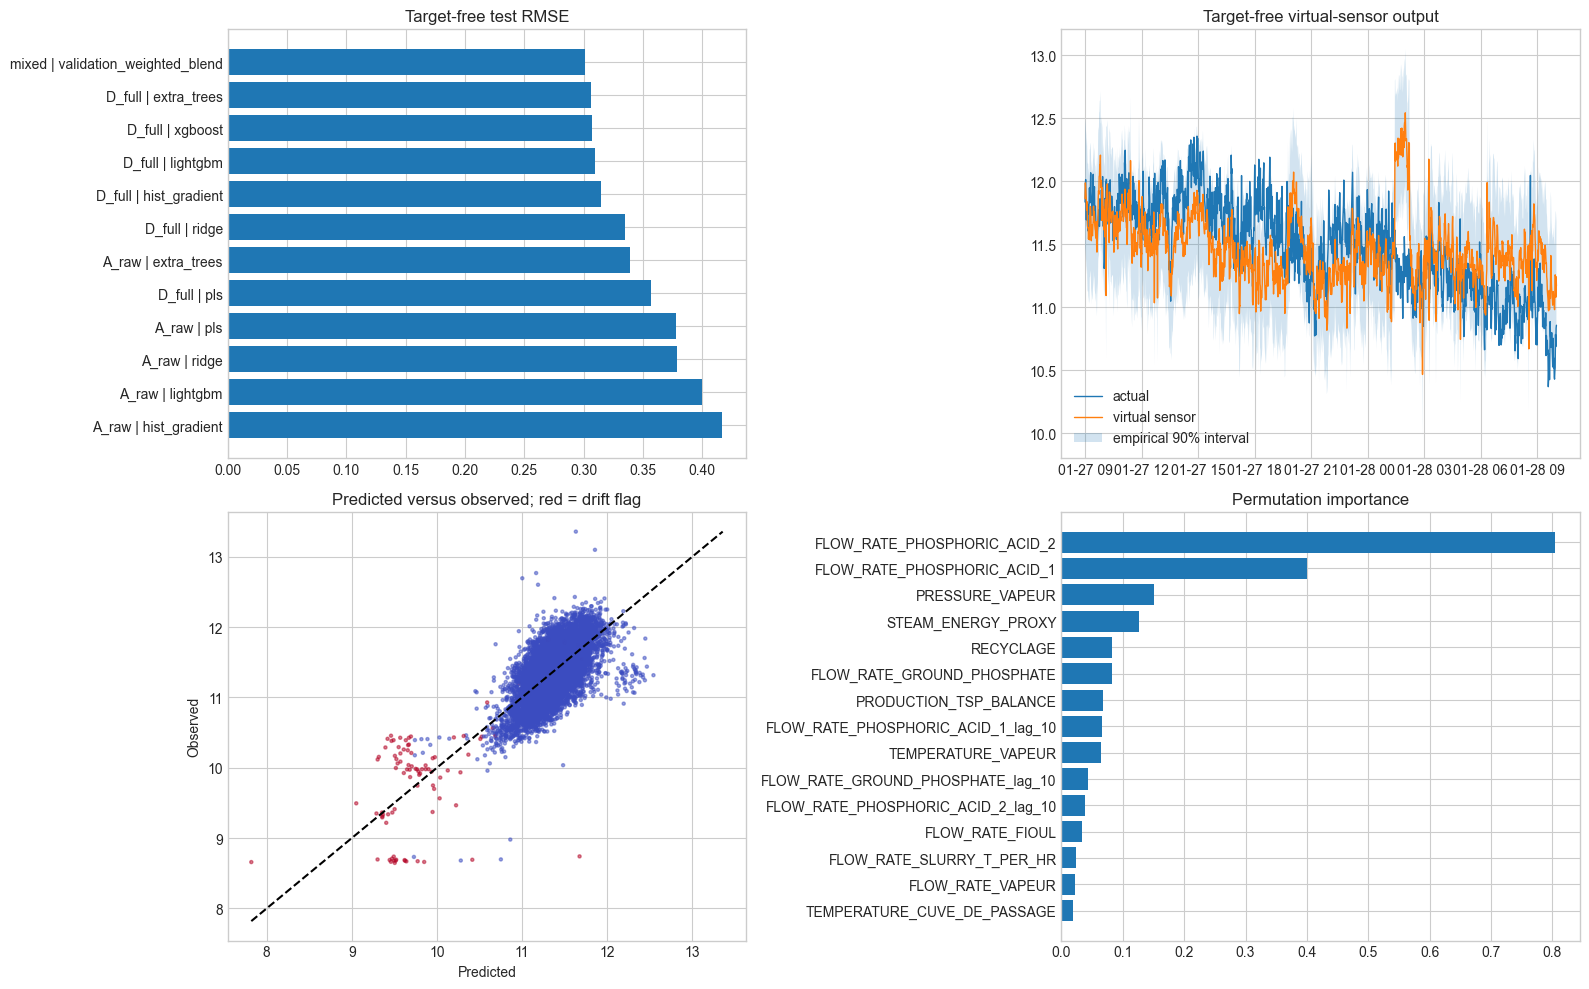

In [21]:
fig,axes=plt.subplots(2,2,figsize=(16,10))
plot_comp=comparison.sort_values("test_rmse").head(12)
axes[0,0].barh((plot_comp.feature_set.fillna('')+' | '+plot_comp.model).iloc[::-1],plot_comp.test_rmse.iloc[::-1])
axes[0,0].set_title("Target-free test RMSE")
window=best_test.head(1500)
axes[0,1].plot(window.timestamp,window.actual,label="actual",linewidth=1)
axes[0,1].plot(window.timestamp,window.prediction,label="virtual sensor",linewidth=1)
axes[0,1].fill_between(window.timestamp,window.lower_90,window.upper_90,alpha=.2,label="empirical 90% interval")
axes[0,1].legend(); axes[0,1].set_title("Target-free virtual-sensor output")
axes[1,0].scatter(best_test.prediction,best_test.actual,c=best_test.outside_training_envelope,cmap="coolwarm",s=5,alpha=.5)
lims=[min(best_test.prediction.min(),best_test.actual.min()),max(best_test.prediction.max(),best_test.actual.max())]
axes[1,0].plot(lims,lims,'k--'); axes[1,0].set(xlabel="Predicted",ylabel="Observed",title="Predicted versus observed; red = drift flag")
top=importance.head(15).sort_values("importance_mean")
axes[1,1].barh(top.feature,top.importance_mean); axes[1,1].set_title("Permutation importance")
fig.tight_layout(); fig.savefig(FIGURE_DIR/"virtual_sensor_performance.png",dpi=180,bbox_inches="tight"); plt.show()


### 11.2 Drift and error stability


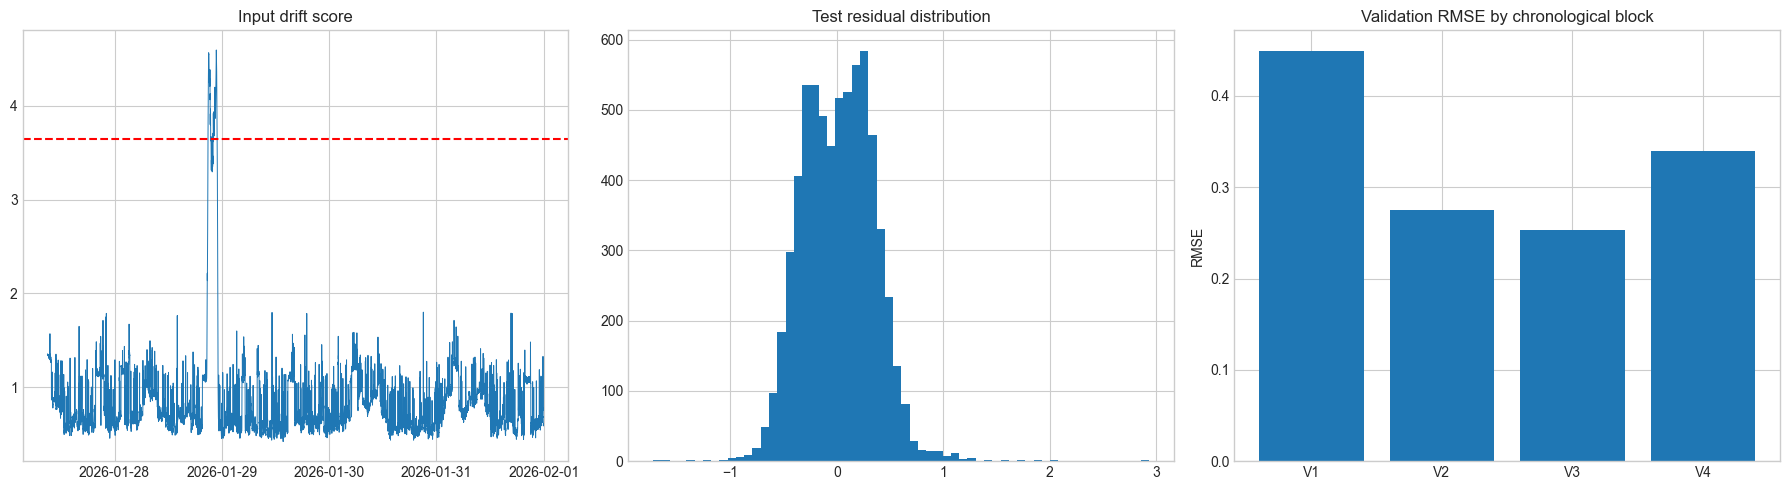

In [22]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].plot(best_test.timestamp,best_test.drift_score,linewidth=.7); axes[0].axhline(drift_threshold,color='red',linestyle='--'); axes[0].set_title("Input drift score")
axes[1].hist(best_test.prediction-best_test.actual,bins=60); axes[1].set_title("Test residual distribution")
axes[2].bar(rolling_validation.validation_block,rolling_validation.rmse); axes[2].set(title="Validation RMSE by chronological block",ylabel="RMSE")
fig.tight_layout(); fig.savefig(FIGURE_DIR/"virtual_sensor_drift_and_stability.png",dpi=180,bbox_inches="tight"); plt.show()


## 12. Exported evidence and readiness


### 12.1 Export all tables


In [23]:
exports={"input_integrity":input_integrity,"dimensions":virtual_sensor_dimensions,"baseline_results":baseline_results,
"search_space":search_space,"hyperparameter_search":hyperparameter_search,"benchmark_results":benchmark_results,
"model_predictions":model_predictions,"blend_search":blend_search,"blend_result":blend_result,"full_comparison":comparison,
"rolling_validation":rolling_validation,"drift_diagnostics":drift_diagnostics,"drift_summary":drift_summary,
"drift_error_metrics":drift_error_metrics,"interval_summary":interval_summary,"test_predictions_with_intervals":best_test,
"target_range_metrics":range_metrics,"largest_errors":largest_errors,"permutation_importance":importance,
"grouped_importance":grouped_importance,"deployment_contract":deployment_contract}
for name,frame in exports.items(): frame.to_csv(OUTPUT_DIR/f"{name}.csv",index=False)
print(f"Exported {len(exports)} tables.")


Exported 21 tables.


### 12.2 Final assertions


In [24]:
readiness=pd.DataFrame([
 {"check":"target_and_target_history_absent_from_inputs","status":input_integrity.target_derived_absent.all()},
 {"check":"chronological_splits_preserved","status":input_integrity.chronological.all()},
 {"check":"notebook02_preprocessing_reused","status":all(len(v["pipelines"])==4 for v in virtual_sensor_data.values())},
 {"check":"validation_only_model_and_blend_selection","status":True},
 {"check":"test_used_once_after_selection","status":True},
 {"check":"all_model_feature_set_keys_unique","status":not benchmark_results.duplicated(["feature_set","model"]).any()},
 {"check":"prediction_timestamps_unique_per_experiment","status":not model_predictions.duplicated(["timestamp","split","feature_set","model"]).any()},
 {"check":"uncertainty_calibrated_on_validation_only","status":True},
 {"check":"drift_score_requires_no_target","status":True},
 {"check":"inference_bundle_exists","status":(MODEL_DIR/"target_free_virtual_sensor_bundle.joblib").exists()},
 {"check":"all_exports_exist","status":all((OUTPUT_DIR/f"{n}.csv").exists() for n in exports)},
 {"check":"no_causal_or_intervention_recommendation","status":True},
])
assert readiness.status.all(); readiness.to_csv(OUTPUT_DIR/"readiness_checks.csv",index=False); display(readiness)


,check,status
0,target_and_target_history_absent_from_inputs,True
1,chronological_splits_preserved,True
2,notebook02_preprocessing_reused,True
3,validation_only_model_and_blend_selection,True
4,test_used_once_after_selection,True
5,all_model_feature_set_keys_unique,True
6,prediction_timestamps_unique_per_experiment,True
7,uncertainty_calibrated_on_validation_only,True
8,drift_score_requires_no_target,True
9,inference_bundle_exists,True


## 13. Final conclusion


### 13.1 Evidence-based answers


In [25]:
winner=comparison.sort_values("valid_rmse").iloc[0]
print(f"Validation-selected target-free candidate: {winner.feature_set} / {winner.model}.")
print(f"Untouched test RMSE={winner.test_rmse:.4f}, MAE={winner.test_mae:.4f}, R2={winner.test_r2:.3f}.")
print(f"Improvement over training-mean baseline={winner.test_rmse_improvement_over_train_mean_pct:.1f}%.")
print(f"Empirical 90% interval coverage={interval_summary.iloc[0].test_empirical_coverage:.3f}; width={interval_summary.iloc[0].mean_interval_width:.3f}.")
print("This model can generate estimates without target input, but cross-month generalization is not proven until a genuinely separate month is supplied.")


Validation-selected target-free candidate: mixed / validation_weighted_blend.
Untouched test RMSE=0.3014, MAE=0.2490, R2=0.558.
Improvement over training-mean baseline=33.6%.
Empirical 90% interval coverage=0.897; width=1.015.
This model can generate estimates without target input, but cross-month generalization is not proven until a genuinely separate month is supplied.


### 13.2 Operational decision

This notebook can establish the strongest **within-month chronological** target-free virtual sensor available from the current data. It cannot honestly “perfect” cross-month performance without another labeled month. The exported bundle is appropriate for offline shadow testing on a new target-free CSV, but accuracy on that month cannot be measured until at least some laboratory or sensor reference values become available.

The next validation should be leave-one-month-out evaluation across several months, stratified by product grade and confirmed operating regime. Unlabeled months can help detect input drift, but they cannot prove target accuracy.
